### Simple test on dual variables calculation

In [8]:
import pyomo.environ as pyo

# Test Pyomo dual sign convention with a simple minimization problem
m = pyo.ConcreteModel()
m.x = pyo.Var(bounds=(0, None))
m.obj = pyo.Objective(expr=m.x, sense=pyo.minimize)
m.p = pyo.Param(initialize=5, mutable=True)
m.con = pyo.Constraint(expr=m.x >= m.p) # x >= 5, so x=5, obj=5. If p increases to 6, obj increases to 6.

m.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
opt = pyo.SolverFactory('gurobi')
opt.solve(m)

print("Constraint x >= p (min x):")
print("Objective:", pyo.value(m.obj))
print("Dual:", m.dual[m.con])

# Test <= constraint
m2 = pyo.ConcreteModel()
m2.x = pyo.Var(bounds=(0, None))
m2.obj = pyo.Objective(expr=-m2.x, sense=pyo.minimize) # maximize x equivalent
m2.p = pyo.Param(initialize=5, mutable=True)
m2.con = pyo.Constraint(expr=m2.x <= m2.p) # x <= 5, so x=5, obj=-5. If p increases to 6, x=6, obj=-6.

m2.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
opt.solve(m2)
print("\nConstraint x <= p (min -x):")
print("Objective:", pyo.value(m2.obj))
print("Dual:", m2.dual[m2.con])

Constraint x >= p (min x):
Objective: 5.0
Dual: 1.0

Constraint x <= p (min -x):
Objective: -5.0
Dual: -1.0


### Toy example of Benders applied to a planning problem
The problem features a BESS and an EL, with the latter having multiple operational statuses (on/off, stand-by)

Starting Benders Decomposition Loops...

Iteration 01 | LB: -10000.00 | UB: 10558.00 | Gap: 194.715%
             | Suggested Sizes -> BESS:  0.00 kW, Electrolyzer:  0.00 kW
Iteration 02 | LB: -8838.92 | UB:  5545.02 | Gap: 259.403%
             | Suggested Sizes -> BESS: 42.68 kW, Electrolyzer: 20.83 kW
Iteration 03 | LB:  5253.15 | UB:  5348.15 | Gap:  1.776%
             | Suggested Sizes -> BESS: 100.00 kW, Electrolyzer: 20.83 kW
Iteration 04 | LB:  5277.23 | UB:  5361.00 | Gap:  1.563%
             | Suggested Sizes -> BESS: 95.27 kW, Electrolyzer: 20.83 kW
Iteration 05 | LB:  5348.15 | UB:  5348.15 | Gap:  0.000%
             | Suggested Sizes -> BESS: 100.00 kW, Electrolyzer: 20.83 kW

Target convergence criteria met successfully!


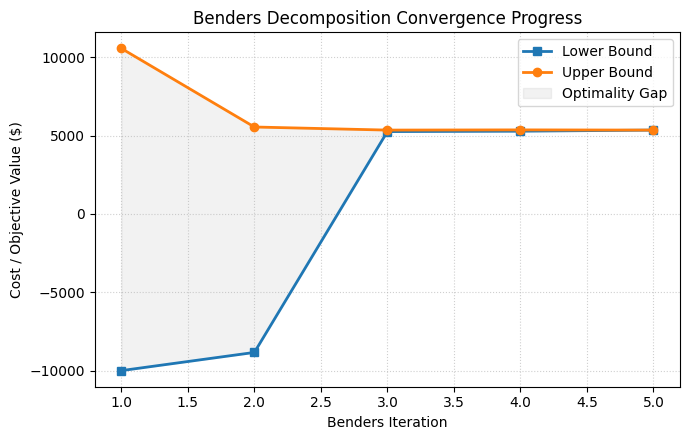

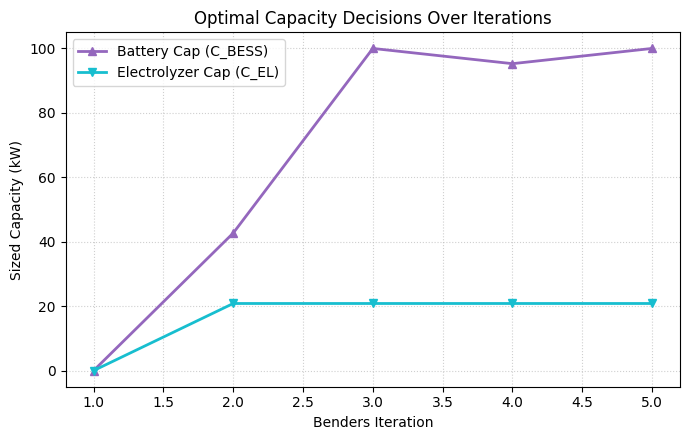

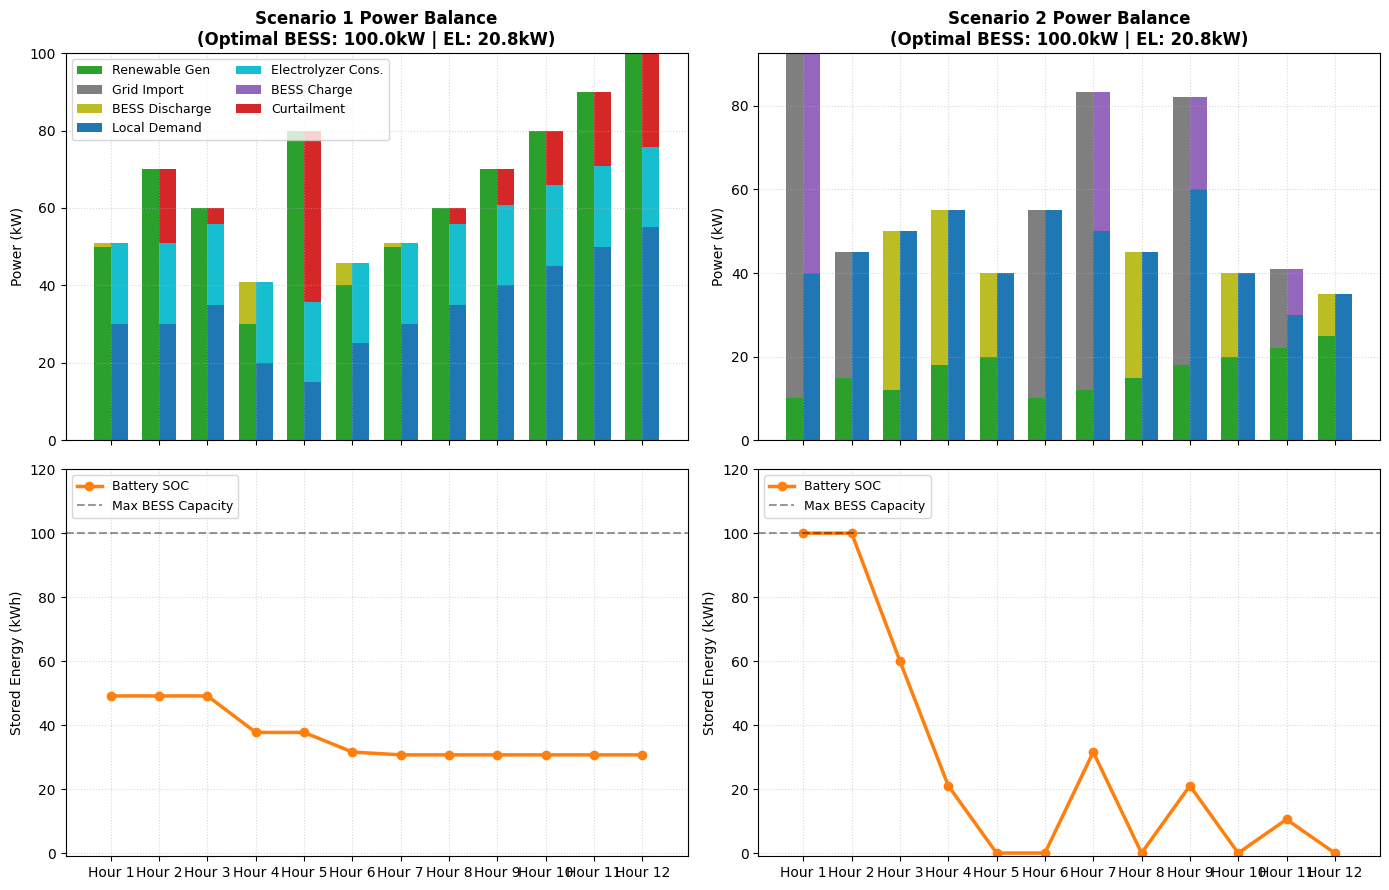

Operational profiles generated and saved as 'optimal_operation_profiles.png'!


In [ ]:
import pyomo.environ as pyo
import matplotlib.pyplot as plt
import numpy as np


# ==========================================
# 1. DATA AND SETS DEFINITION
# ==========================================
# T = [1, 2]        # Time periods (hours)
T = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]        # Time periods (hours)
S = [1, 2]        # Stochastic Scenarios
prob = {1: 0.5, 2: 0.5}  # Scenario probabilities

# Scenario Data: Renewable Generation, Local Demand, and Grid Purchase Prices
data = {
    # 1: {'RenewableGen': {1: 50, 2: 70}, 'Demand': {1: 30, 2: 30}, 'GridPrice': {1: 20, 2: 15}},
    # 2: {'RenewableGen': {1: 10, 2: 15}, 'Demand': {1: 40, 2: 45}, 'GridPrice': {1: 50, 2: 60}}
    1: {'RenewableGen': {1: 50, 2: 70, 3: 60, 4: 30, 5: 80, 6: 40, 7: 50, 8: 60, 9: 70, 10: 80, 11: 90, 12: 100},
        'Demand': {1: 30, 2: 30, 3: 35, 4: 20, 5: 15, 6: 25, 7: 30, 8: 35, 9: 40, 10: 45, 11: 50, 12: 55},
        'GridPrice': {1: 20, 2: 15, 3: 18, 4: 22, 5: 25, 6: 30, 7: 28, 8: 26, 9: 24, 10: 22, 11: 20, 12: 18}},
    2: {'RenewableGen': {1: 10, 2: 15, 3: 12, 4: 18, 5: 20, 6: 10, 7: 12, 8: 15, 9: 18, 10: 20, 11: 22, 12: 25},
        'Demand': {1: 40, 2: 45, 3: 50, 4: 55, 5: 40, 6: 55, 7: 50, 8: 45, 9: 60, 10: 40, 11: 30, 12: 35},
        'GridPrice': {1: 50, 2: 60, 3: 65, 4: 70, 5: 75, 6: 60, 7: 55, 8: 70, 9: 50, 10: 62, 11: 47, 12: 65}}
}

# Investment Costs
COST_BESS = 15.0  # $/kW
COST_EL = 25.0    # $/kW
M = 100.0         # Big-M value for linearization (matches max device capacity)

# ==========================================
# 2. MASTER PROBLEM SETUP (MILP)
# ==========================================
master = pyo.ConcreteModel()

# First-Stage Complicating Variables
master.C_BESS = pyo.Var(bounds=(0, 100))
master.C_EL = pyo.Var(bounds=(0, 100))
master.u_on = pyo.Var(S, T, within=pyo.Binary)
master.u_sb = pyo.Var(S, T, within=pyo.Binary) # Standby status

# Linearization tracking variables: z = Capacity * binary
master.z_on = pyo.Var(S, T, bounds=(0, 100))
master.z_sb = pyo.Var(S, T, bounds=(0, 100))

# Benders operational cost estimators per scenario
master.theta = pyo.Var(S, bounds=(-10000, None))

# Master Constraints
master.cons_status = pyo.ConstraintList()
master.cons_linearize = pyo.ConstraintList()
master.benders_cuts = pyo.ConstraintList()

for s in S:
    for t in T:
        # Mutually exclusive operational statuses (On + Standby <= 1)
        master.cons_status.add(master.u_on[s, t] + master.u_sb[s, t] <= 1)
        
        # Linearization for z_on = C_EL * u_on
        master.cons_linearize.add(master.z_on[s, t] <= master.C_EL)
        master.cons_linearize.add(master.z_on[s, t] <= M * master.u_on[s, t])
        master.cons_linearize.add(master.z_on[s, t] >= master.C_EL - M * (1 - master.u_on[s, t]))
        master.cons_linearize.add(master.z_on[s, t] >= 0)
        
        # Linearization for z_sb = C_EL * u_sb
        master.cons_linearize.add(master.z_sb[s, t] <= master.C_EL)
        master.cons_linearize.add(master.z_sb[s, t] <= M * master.u_sb[s, t])
        master.cons_linearize.add(master.z_sb[s, t] >= master.C_EL - M * (1 - master.u_sb[s, t]))
        master.cons_linearize.add(master.z_sb[s, t] >= 0)

# Master Objective: Capital Expenditure + Expected Operational Cost Proxy
master.obj = pyo.Objective(
    expr=COST_BESS * master.C_BESS + COST_EL * master.C_EL + sum(prob[s] * master.theta[s] for s in S),
    sense=pyo.minimize
)

# ==========================================
# 3. SUBPROBLEM SETUP (LP)
# ==========================================
def create_subproblem():
    sub = pyo.ConcreteModel()
    
    # Placeholders for incoming fixed Master values
    sub.p_C_BESS = pyo.Param(mutable=True, initialize=0.0)
    sub.p_z_on = pyo.Param(T, mutable=True, initialize=0.0)
    sub.p_z_sb = pyo.Param(T, mutable=True, initialize=0.0)
    
    # Placeholders for changing scenario data
    sub.p_RenewableGen = pyo.Param(T, mutable=True)
    sub.p_Demand = pyo.Param(T, mutable=True)
    sub.p_GridPrice = pyo.Param(T, mutable=True)
    
    # Continuous dummy variables to track Master boundaries
    sub.BESS_cap = pyo.Var(bounds=(0, 100))
    sub.EL_z_on = pyo.Var(T, bounds=(0, 100))
    sub.EL_z_sb = pyo.Var(T, bounds=(0, 100))
    sub.P_curt = pyo.Var(T, bounds=(0, None)) # Renewable power curtailed/dumped
    
    # EXPLICIT EQUALITY LINKING CONSTRAINTS (Crucial for clean shadow prices)
    sub.link_BESS = pyo.Constraint(expr=sub.BESS_cap == sub.p_C_BESS)
    sub.link_z_on = pyo.Constraint(T, rule=lambda m, t: m.EL_z_on[t] == m.p_z_on[t])
    sub.link_z_sb = pyo.Constraint(T, rule=lambda m, t: m.EL_z_sb[t] == m.p_z_sb[t])
    
    # Operational continuous variables
    sub.P_EL = pyo.Var(T, bounds=(0, 100))
    sub.P_ch = pyo.Var(T, bounds=(0, 100))
    sub.P_dis = pyo.Var(T, bounds=(0, 100))
    sub.SOC = pyo.Var(T, bounds=(0, 100))
    sub.P_grid = pyo.Var(T, bounds=(0, None))
    sub.P_shed = pyo.Var(T, bounds=(0, None)) # High-cost penalty to guarantee feasibility
    
    # Device Constraints using the bounds handed down by the Master Problem
    # Operating range when ON: [20%, 100%]. When Standby: Exactly 5% consumption.
    sub.con_EL_max = pyo.Constraint(T, rule=lambda m, t: m.P_EL[t] <= m.EL_z_on[t] + 0.05 * m.EL_z_sb[t])
    sub.con_EL_min = pyo.Constraint(T, rule=lambda m, t: m.P_EL[t] >= 0.2 * m.EL_z_on[t] + 0.05 * m.EL_z_sb[t])
    
    sub.con_ch_max = pyo.Constraint(T, rule=lambda m, t: m.P_ch[t] <= m.BESS_cap)
    sub.con_dis_max = pyo.Constraint(T, rule=lambda m, t: m.P_dis[t] <= m.BESS_cap)
    sub.con_SOC_max = pyo.Constraint(T, rule=lambda m, t: m.SOC[t] <= m.BESS_cap)
    
    def soc_tracking_rule(m, t):
        if t == 1:
            return m.SOC[1] == 0.5 * m.BESS_cap + 0.95 * m.P_ch[1] - m.P_dis[1] / 0.95
        return m.SOC[t] == m.SOC[t-1] + 0.95 * m.P_ch[t] - m.P_dis[t] / 0.95
    sub.con_SOC_track = pyo.Constraint(T, rule=soc_tracking_rule)
    
    def balance_rule(m, t):
    # (Excess renewables can flow into m.P_curt[t])
        return m.p_RenewableGen[t] + m.P_grid[t] + m.P_dis[t] + m.P_shed[t] == m.p_Demand[t] + m.P_EL[t] + m.P_ch[t] + m.P_curt[t]
    sub.con_balance = pyo.Constraint(T, rule=balance_rule)
    
    # Subproblem Objective: Minimize purchase cost + shedding penalties - Hydrogen revenue
    sub.obj = pyo.Objective(
        expr=sum(sub.p_GridPrice[t] * sub.P_grid[t] + 1000 * sub.P_shed[t] - 40 * sub.P_EL[t] for t in T),
        sense=pyo.minimize
    )
    
    # Activate Dual suffix collection
    sub.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    return sub


# ==========================================
# 4. MANUAL BENDERS DECOMPOSITION LOOP
# ==========================================
# --- Place this BEFORE your loop to initialize history tracking ---
history_lb = []
history_ub = []
history_bess = []
history_el = []

master_opt = pyo.SolverFactory('gurobi')
sub_opt = pyo.SolverFactory('gurobi')
subproblem = create_subproblem()

MAX_ITER = 15
TOLERANCE = 0.0005 # 0.05% Gap Convergence Target

print("Starting Benders Decomposition Loops...\n")

for iteration in range(1, MAX_ITER + 1):
    # Step A: Solve Master Problem
    master_opt.solve(master, tee=False)
    
    # Extract current candidate sizes from Master
    hat_C_BESS = pyo.value(master.C_BESS)
    hat_C_EL = pyo.value(master.C_EL)
    
    investment_cost = COST_BESS * hat_C_BESS + COST_EL * hat_C_EL
    lower_bound = pyo.value(master.obj)
    
    total_expected_sub_obj = 0.0
    
    # Step B: Loop through independent scenarios sequentially
    for s in S:
        # Load data specific to scenario s into the subproblem
        for t in T:
            subproblem.p_RenewableGen[t] = data[s]['RenewableGen'][t]
            subproblem.p_Demand[t] = data[s]['Demand'][t]
            subproblem.p_GridPrice[t] = data[s]['GridPrice'][t]
            subproblem.p_z_on[t] = pyo.value(master.z_on[s, t])
            subproblem.p_z_sb[t] = pyo.value(master.z_sb[s, t])
        subproblem.p_C_BESS = hat_C_BESS
        
        # Solve Subproblem (LP)
        sub_opt.solve(subproblem, tee=False)
        sub_obj_val = pyo.value(subproblem.obj)
        total_expected_sub_obj += prob[s] * sub_obj_val
        
        # Step C: Extract Dual Values (Shadow Prices)
        dual_BESS = subproblem.dual[subproblem.link_BESS]
        
        # Build the dynamic cuts based on the duality sensitivity property
        cut_expr = sub_obj_val + dual_BESS * (master.C_BESS - hat_C_BESS)
        for t in T:
            dual_on = subproblem.dual[subproblem.link_z_on[t]]
            dual_sb = subproblem.dual[subproblem.link_z_sb[t]]
            
            cut_expr += dual_on * (master.z_on[s, t] - pyo.value(master.z_on[s, t]))
            cut_expr += dual_sb * (master.z_sb[s, t] - pyo.value(master.z_sb[s, t]))
        
        # Feed the new optimality cut back to Master
        master.benders_cuts.add(master.theta[s] >= cut_expr)
        
    upper_bound = investment_cost + total_expected_sub_obj
    gap = (upper_bound - lower_bound) / abs(upper_bound)
    
    # --- Inside your Benders loop, append the data right before printing ---
    history_lb.append(lower_bound)
    history_ub.append(upper_bound)
    history_bess.append(hat_C_BESS)
    history_el.append(hat_C_EL)

    print(f"Iteration {iteration:02d} | LB: {lower_bound:8.2f} | UB: {upper_bound:8.2f} | Gap: {gap*100:6.3f}%")
    print(f"             | Suggested Sizes -> BESS: {hat_C_BESS:5.2f} kW, Electrolyzer: {hat_C_EL:5.2f} kW")
    
    if gap <= TOLERANCE:
        print("\nTarget convergence criteria met successfully!")
        break


# --- Place this AFTER your loop breaks to generate the visual summaries ---
iterations = np.arange(1, len(history_lb) + 1)

# Plot 1: Objective Convergence
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(iterations, history_lb, marker='s', color='#1f77b4', linewidth=2, label='Lower Bound')
ax.plot(iterations, history_ub, marker='o', color='#ff7f0e', linewidth=2, label='Upper Bound')
ax.fill_between(iterations, history_lb, history_ub, color='gray', alpha=0.1, label='Optimality Gap')
ax.set_xlabel('Benders Iteration')
ax.set_ylabel('Cost / Objective Value ($)')
ax.set_title('Benders Decomposition Convergence Progress')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend()
plt.tight_layout()
# plt.savefig('benders_convergence.png', dpi=150)
# plt.close()

# Plot 2: Capacity Sizing Trace
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(iterations, history_bess, marker='^', color='#9467bd', linewidth=2, label='Battery Cap (C_BESS)')
ax.plot(iterations, history_el, marker='v', color='#17becf', linewidth=2, label='Electrolyzer Cap (C_EL)')
ax.set_xlabel('Benders Iteration')
ax.set_ylabel('Sized Capacity (kW)')
ax.set_title('Optimal Capacity Decisions Over Iterations')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend()
plt.tight_layout()
# plt.savefig('capacity_decisions.png', dpi=150)
# plt.close()

# print("Plots saved successfully to your working directory!")


# ==========================================
# 1. RECOVER OPTIMAL OPERATIONAL DATA
# ==========================================
# Dictionaries to store trajectories per scenario
operational_results = {s: {
    'Renewables': [], 'Demand': [], 'Grid_Buy': [], 
    'BESS_Ch': [], 'BESS_Dis': [], 'BESS_SOC': [], 
    'Electrolyzer': [], 'Curtailment': []
} for s in S}

# Run a clean final pass using the optimized Master capacities
opt_C_BESS = pyo.value(master.C_BESS)

for s in S:
    # Load optimal Master decisions and scenario data into the subproblem
    for t in T:
        subproblem.p_RenewableGen[t] = data[s]['RenewableGen'][t]
        subproblem.p_Demand[t] = data[s]['Demand'][t]
        subproblem.p_GridPrice[t] = data[s]['GridPrice'][t]
        subproblem.p_z_on[t] = pyo.value(master.z_on[s, t])
        subproblem.p_z_sb[t] = pyo.value(master.z_sb[s, t])
    subproblem.p_C_BESS = opt_C_BESS
    
    # Solve final dispatch
    sub_opt.solve(subproblem, tee=False)
    
    # Extract values across the time horizon
    for t in T:
        operational_results[s]['Renewables'].append(data[s]['RenewableGen'][t])
        operational_results[s]['Demand'].append(data[s]['Demand'][t])
        operational_results[s]['Grid_Buy'].append(pyo.value(subproblem.P_grid[t]))
        operational_results[s]['BESS_Ch'].append(pyo.value(subproblem.P_ch[t]))
        operational_results[s]['BESS_Dis'].append(pyo.value(subproblem.P_dis[t]))
        operational_results[s]['BESS_SOC'].append(pyo.value(subproblem.SOC[t]))
        operational_results[s]['Electrolyzer'].append(pyo.value(subproblem.P_EL[t]))
        operational_results[s]['Curtailment'].append(pyo.value(subproblem.P_curt[t]))

# ==========================================
# 2. GENERATE DISPATCH & SOC PLOTS
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
time_steps = [f"Hour {t}" for t in T]
x = np.arange(len(time_steps))
width = 0.35

for idx, s in enumerate(S):
    res = operational_results[s]
    
    # --- TOP ROW: POWER BALANCE DISPATCH ---
    ax_p = axs[0, idx]
    
    # Generation Side (Left Bar)
    gen_bars = ax_p.bar(x - width/2, res['Renewables'], width, label='Renewable Gen', color='#2ca02c')
    grid_bars = ax_p.bar(x - width/2, res['Grid_Buy'], width, bottom=res['Renewables'], label='Grid Import', color='#7f7f7f')
    dis_bars = ax_p.bar(x - width/2, res['BESS_Dis'], width, bottom=np.array(res['Renewables'])+np.array(res['Grid_Buy']), label='BESS Discharge', color='#bcbd22')
    
    # Consumption Side (Right Bar)
    dem_bars = ax_p.bar(x + width/2, res['Demand'], width, label='Local Demand', color='#1f77b4')
    el_bars = ax_p.bar(x + width/2, res['Electrolyzer'], width, bottom=res['Demand'], label='Electrolyzer Cons.', color='#17becf')
    ch_bars = ax_p.bar(x + width/2, res['BESS_Ch'], width, bottom=np.array(res['Demand'])+np.array(res['Electrolyzer']), label='BESS Charge', color='#9467bd')
    curt_bars = ax_p.bar(x + width/2, res['Curtailment'], width, bottom=np.array(res['Demand'])+np.array(res['Electrolyzer'])+np.array(res['BESS_Ch']), label='Curtailment', color='#d62728')
    
    ax_p.set_title(f"Scenario {s} Power Balance\n(Optimal BESS: {opt_C_BESS:.1f}kW | EL: {pyo.value(master.C_EL):.1f}kW)", fontsize=12, fontweight='bold')
    ax_p.set_ylabel("Power (kW)")
    ax_p.set_xticks(x)
    ax_p.set_xticklabels(time_steps)
    ax_p.grid(True, linestyle=':', alpha=0.5)
    if idx == 0:
        ax_p.legend(loc='upper left', bbox_to_anchor=(0.0, 1.0), ncol=2, fontsize=9)
        
    # --- BOTTOM ROW: STATE OF CHARGE (SOC) ---
    ax_s = axs[1, idx]
    ax_s.plot(time_steps, res['BESS_SOC'], color='#ff7f0e', marker='o', linewidth=2.5, linestyle='-', label='Battery SOC')
    # Draw capacity limit line
    ax_s.axhline(y=opt_C_BESS, color='black', linestyle='--', alpha=0.4, label='Max BESS Capacity')
    
    ax_s.set_ylabel("Stored Energy (kWh)")
    ax_s.set_ylim(-1, max(opt_C_BESS * 1.2, 5))
    ax_s.grid(True, linestyle=':', alpha=0.5)
    ax_s.legend(loc='upper left', fontsize=9)

plt.tight_layout()
# plt.savefig('optimal_operation_profiles.png', dpi=150)
# plt.show()
# print("Operational profiles generated and saved as 'optimal_operation_profiles.png'!")